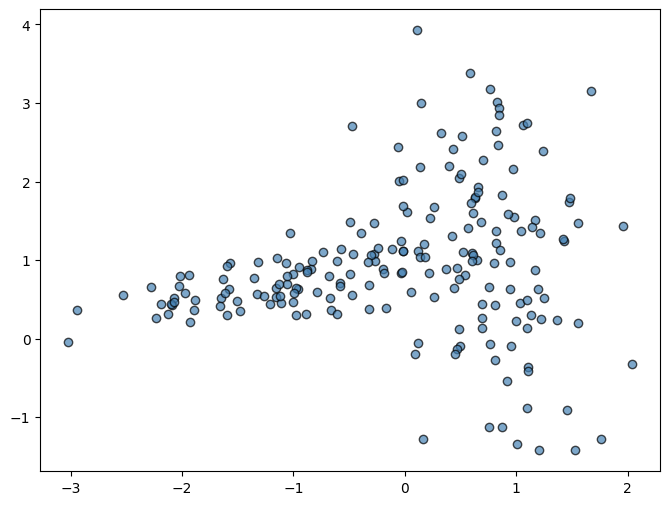

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, _ = make_classification(n_samples=200, 
                           n_features=2, 
                           n_informative=2, 
                           n_redundant=0, 
                           random_state=0, 
                           n_clusters_per_class=1, 
                           class_sep=0.8)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='steelblue', edgecolors='k', alpha=0.7)
plt.show()

In [31]:
def init_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def compute_distances(X, centroids):
    return np.array([np.linalg.norm(X - c, axis=1) for c in centroids])

def compute_cost(X, centroids, closest_centroids):
    total_dist = 0
    for i, c in enumerate(centroids):
        points_in_cluster = X[closest_centroids == i]
        if len(points_in_cluster) > 0:
            total_dist += np.sum(np.linalg.norm(points_in_cluster - c, axis=1)**2)
    return total_dist / X.shape[0]

In [32]:
def run_k_means(X, k, max_iters=100):
    centroids = init_centroids(X, k)
    prev_centroids = None
    
    for _ in range(max_iters):
        distances = compute_distances(X, centroids)
        closest_centroids = np.argmin(distances, axis=0)
        
        prev_centroids = centroids.copy()
        new_centroids = []
        for i in range(k):
            points_in_cluster = X[closest_centroids == i]
            if len(points_in_cluster) > 0:
                new_centroids.append(np.mean(points_in_cluster, axis=0))
            else:
                new_centroids.append(X[np.random.choice(X.shape[0])]) # якщо кластер пустий
        
        centroids = np.array(new_centroids)
        
        if np.all(prev_centroids == centroids):
            break
            
    cost = compute_cost(X, centroids, closest_centroids)
    return centroids, closest_centroids, cost

In [33]:
best_cost = float('inf')
best_centroids = None
best_clusters = None

for i in range(100):
    curr_centroids, curr_clusters, curr_cost = run_k_means(X, k=4)
    
    if curr_cost < best_cost:
        best_cost = curr_cost
        best_centroids = curr_centroids
        best_clusters = curr_clusters

print(f"best j after 100: {best_cost:.4f}")

best j after 100: 0.4577


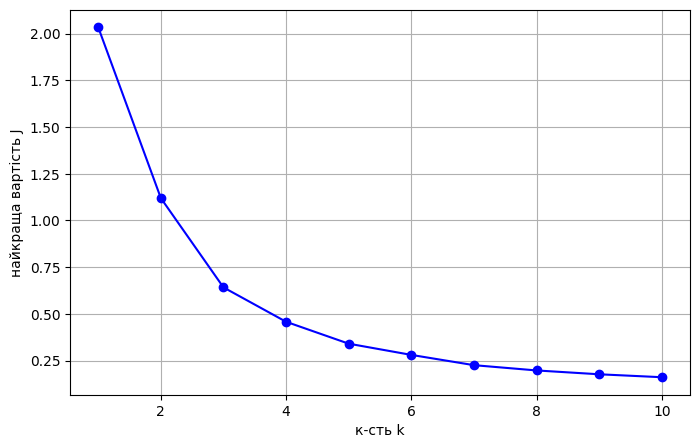

In [34]:
k_range = range(1, 11)
best_costs = []

for k in k_range:
    best_cost_for_k = float('inf')
    
    for _ in range(100):
        _, _, current_cost = run_k_means(X, k)
        if current_cost < best_cost_for_k:
            best_cost_for_k = current_cost
            
    best_costs.append(best_cost_for_k)

plt.figure(figsize=(8, 5))
plt.plot(k_range, best_costs, 'bo-')
plt.xlabel('к-сть k')
plt.ylabel('найкраща вартість J')
plt.grid(True)
plt.show()

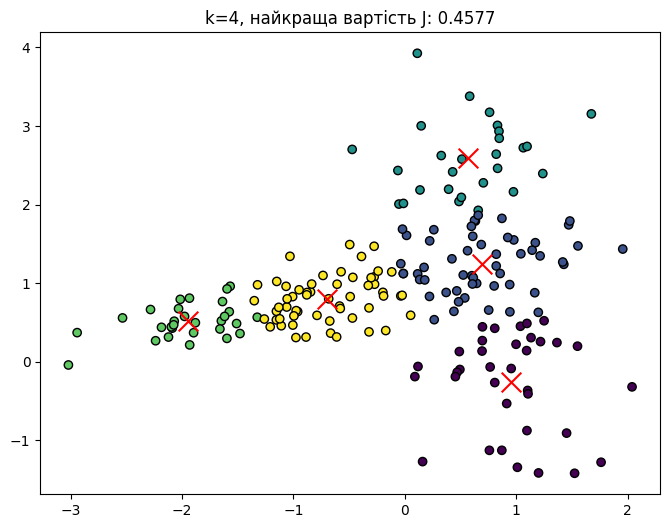

In [38]:
final_centroids, final_clusters, _ = run_k_means(X, k=5)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_clusters, cmap='viridis', edgecolors='k')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='x', s=200)
plt.title(f"k=4, найкраща вартість J: {best_cost:.4f}")
plt.show()